# Cold Plasma Waveguide with ML Warm-Start

This notebook demonstrates using the **pre-trained ML warm-start model** to
accelerate VQE convergence for plasma-filled waveguides.

The warm-start predictor replaces random initialisation of the variational
circuit parameters with a learned prediction from an MLP, typically reducing
the number of optimisation iterations by 30-60%.

**Prerequisites:** Run notebook `03_train_ml_warmstart.ipynb` first, or use
the pre-trained models shipped in `warmstart_models/`.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.ml_warmstart_vqe import WarmStartPredictor, WarmStartVQA
from src.coldplasma_vqe_waveguide import WaveguideModeVQA
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

MODEL_DIR = os.path.join('..', 'warmstart_models')
DATA_PATH = os.path.join('..', 'data', 'warmstart_data.json')

## 1. Load Pre-Trained Predictor

In [3]:
predictor = WarmStartPredictor(
    data_path=DATA_PATH,
    model_dir=MODEL_DIR,
)

print('Available warm-start models:')
for key in predictor.trained_keys():
    print(f'  [ok] {key}')

if not predictor.trained_keys():
    print('  WARNING: No trained models found.')
    print('  Run notebook 03_train_ml_warmstart.ipynb first!')

  Loaded model for 'nx2_ny2_nl2_mtTE_k1'
  Loaded model for 'nx2_ny2_nl2_mtTM_k1'
  Loaded model for 'nx2_ny2_nl2_mtTM_k0'
  Loaded model for 'nx2_ny2_nl2_mtTE_k0'
Available warm-start models:
  [ok] nx2_ny2_nl2_mtTE_k1
  [ok] nx2_ny2_nl2_mtTM_k1
  [ok] nx2_ny2_nl2_mtTM_k0
  [ok] nx2_ny2_nl2_mtTE_k0


## 2. Solve with ML Warm-Start

`WarmStartVQA` is a drop-in replacement for `WaveguideModeVQA`.
It uses the ML prediction on the first attempt, falling back to random init if needed.

Solving with ML warm-start...
[WarmStart] Using ML prediction for mode 0.
Attempt 1 - Iter 15: Cost 138922.8827    
Mode 0 Result:
Eigenvalue λ = ω²/c² : 138922.882724991 m⁻²
Wave frequency  ω/(2π)  : 17.783929 GHz
(Plasma mode: eigenvalue includes ωp²/c² shift)

Numerical Eigenvalue (dense) : 138922.882724598 m⁻²
Cutoff / wave freq (numerical): 17.783929493 GHz
Relative Error vs numerical   : 0.000000000%


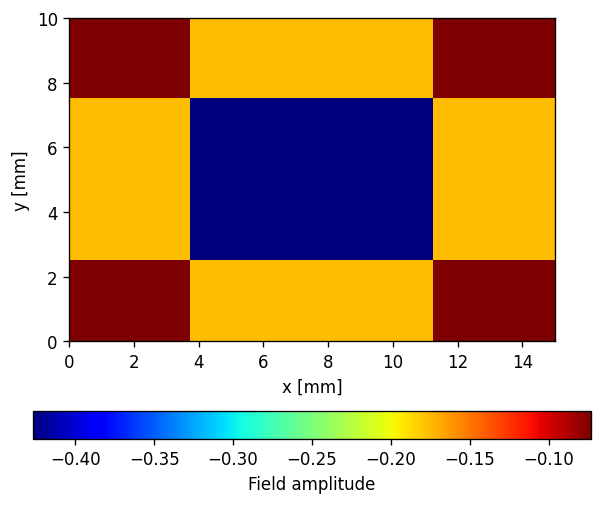

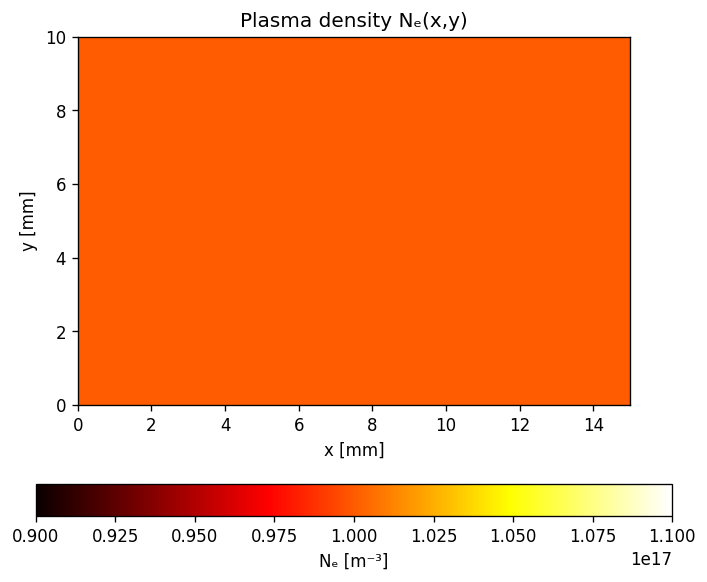

In [4]:
Lx, Ly = 0.015, 0.010
nx, ny = 2, 2
n_layers = 2
NE = 1e17

solver_warm = WarmStartVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM',
    Lx=Lx, Ly=Ly,
    plasma_density=NE,
    predictor=predictor,
    warm_start_noise=0.05,
)

print('Solving with ML warm-start...')
eig_w, params_w, hist_w = solver_warm.optimize_mode(k=0)
solver_warm.print_plot_parameters(0, eig_w, params_w)

## 3. Compare: Random Init vs ML Warm-Start

Solving with random initialisation...
Attempt 1 - Iter 18: Cost 138922.8828    
Mode 0 Result:
Eigenvalue λ = ω²/c² : 138922.882786660 m⁻²
Wave frequency  ω/(2π)  : 17.783929 GHz
(Plasma mode: eigenvalue includes ωp²/c² shift)

Numerical Eigenvalue (dense) : 138922.882724598 m⁻²
Cutoff / wave freq (numerical): 17.783929493 GHz
Relative Error vs numerical   : 0.000000022%


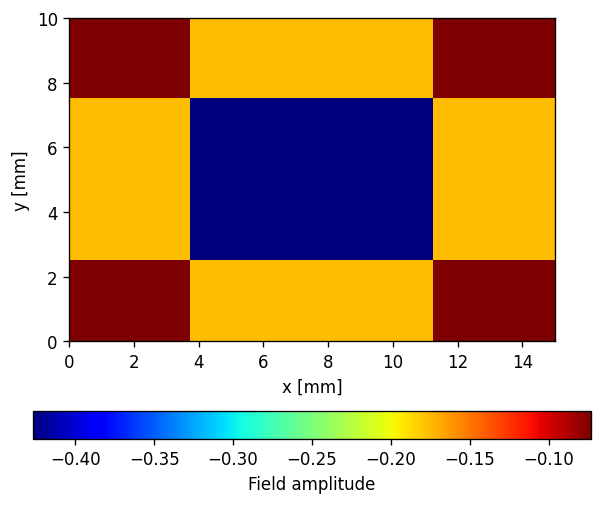

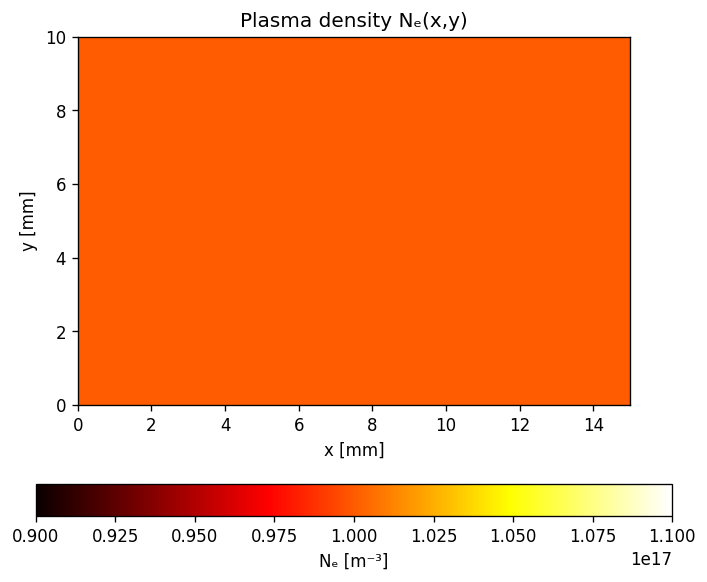

In [5]:
solver_random = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM',
    Lx=Lx, Ly=Ly,
    plasma_density=NE,
)

print('Solving with random initialisation...')
eig_r, params_r, hist_r = solver_random.optimize_mode(k=0)
solver_random.print_plot_parameters(0, eig_r, params_r)

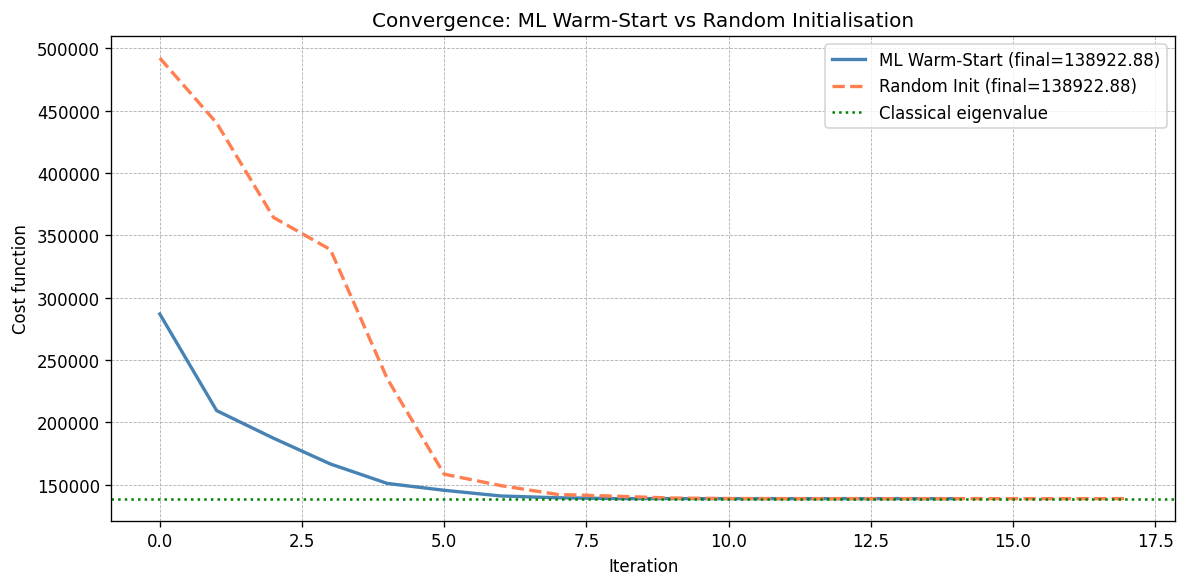


ML warm-start iterations : 15
Random init iterations   : 18
Speed-up                 : 1.2x


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_w, label=f'ML Warm-Start (final={eig_w:.2f})', color='steelblue', lw=2)
ax.plot(hist_r, label=f'Random Init (final={eig_r:.2f})', color='coral', lw=2, ls='--')

classical_eigs = np.sort(np.linalg.eigvalsh(solver_warm.M_dense))
classical_eigs = [e for e in classical_eigs if e > 0]
ax.axhline(classical_eigs[0], color='green', ls=':', lw=1.5, label='Classical eigenvalue')

ax.set_xlabel('Iteration')
ax.set_ylabel('Cost function')
ax.set_title('Convergence: ML Warm-Start vs Random Initialisation')
ax.legend()
ax.grid(True, ls='--', lw=0.5)
plt.tight_layout()
plt.show()

print(f'\nML warm-start iterations : {len(hist_w)}')
print(f'Random init iterations   : {len(hist_r)}')
print(f'Speed-up                 : {len(hist_r)/max(len(hist_w),1):.1f}x')

## 4. Higher-Resolution Grid

The predictor must have been trained for this configuration, otherwise
it gracefully falls back to random init.

Grid: 8x8, Qubits: 6, Layers: 6
Solving...
[WarmStart] No model for this config — falling back to saved params / random.
Attempt 1 - Iter 81: Cost 144279.4172    
Mode 0 Result:
Eigenvalue λ = ω²/c² : 144279.417185611 m⁻²
Wave frequency  ω/(2π)  : 18.123540 GHz
(Plasma mode: eigenvalue includes ωp²/c² shift)

Numerical Eigenvalue (dense) : 144279.414807734 m⁻²
Cutoff / wave freq (numerical): 18.123539582 GHz
Relative Error vs numerical   : 0.000000824%


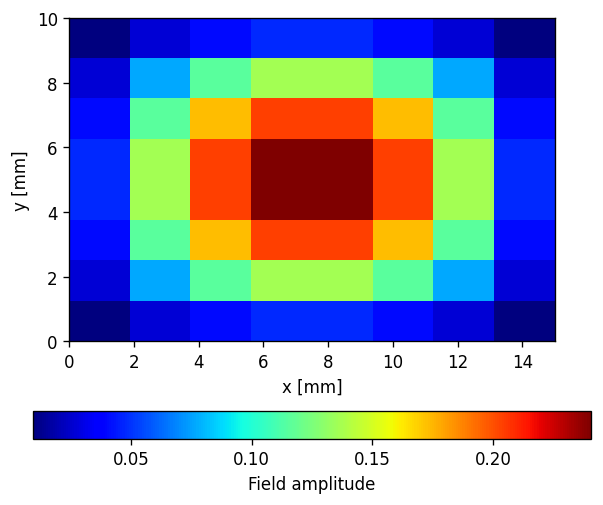

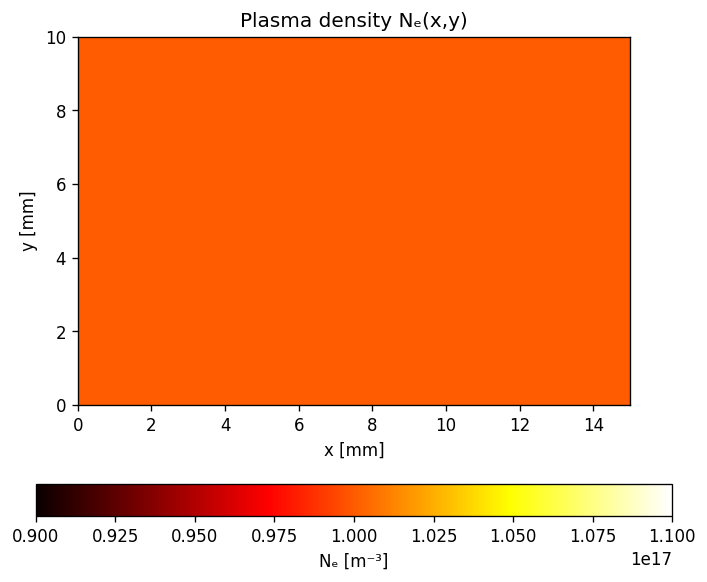

In [7]:
nx_big, ny_big = 3, 3
n_layers_big = nx_big + ny_big

solver_big = WarmStartVQA(
    nx=nx_big, ny=ny_big, n_layers=n_layers_big,
    mode_type='TM',
    Lx=Lx, Ly=Ly,
    plasma_density=NE,
    predictor=predictor,
    warm_start_noise=0.05,
)

print(f'Grid: {2**nx_big}x{2**ny_big}, Qubits: {nx_big+ny_big}, Layers: {n_layers_big}')
print('Solving...')
eig_big, params_big, hist_big = solver_big.optimize_mode(k=0)
solver_big.print_plot_parameters(0, eig_big, params_big)

## 5. Summary

The ML warm-start approach provides:

- **Faster convergence** — fewer VQE iterations needed
- **More reliable** — avoids poor local minima from random starts
- **Transferable** — once trained, predictions are instant